In [73]:
import seaborn as sns 
import pandas as pd
import numpy as np 

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

import glob 
import os 


Data retrieval and preprocessing 

In [74]:
# import data and perform data slicing
df= pd.read_csv("./ecgmotion_combined.csv")
df = df.iloc[0:201,1:]
#df.to_csv('./processed_ecgmotion.csv')
df

,Jump,Jump.1,Jump.2,Jump.3,Jump.4,Jump.5,Jump.6,Jump.7,Jump.8,Jump.9,...,Walk.43,Walk.44,Walk.45,Walk.46,Walk.47,Walk.48,Walk.49,Walk.50,Walk.51,Walk.52
0,3051.0,3362.0,892.0,3724.0,2682.0,2721.0,2168.0,2998.0,2090.0,1222.0,...,1662.0,1648.0,1780.0,1762.0,1560.0,1496,1516.0,2016.0,2126.0,1851.0
1,3109.0,3586.0,799.0,4050.0,2683.0,2357.0,2576.0,3049.0,2083.0,772.0,...,1843.0,1716.0,1800.0,1797.0,1451.0,1501,1733.0,2048.0,2319.0,1938.0
2,2245.0,3714.0,800.0,2568.0,2588.0,2453.0,2116.0,3130.0,2070.0,859.0,...,1846.0,1845.0,1806.0,1797.0,1279.0,1645,1824.0,2148.0,2375.0,1865.0
3,1755.0,3459.0,826.0,1423.0,2483.0,2100.0,2102.0,2768.0,2006.0,1646.0,...,1850.0,1990.0,1847.0,3108.0,1245.0,1757,1959.0,2288.0,2428.0,1855.0
4,1319.0,3404.0,952.0,576.0,2095.0,1714.0,1917.0,2969.0,2318.0,1641.0,...,1816.0,2080.0,1861.0,2767.0,1401.0,1816,1952.0,2248.0,2393.0,1899.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
196,2648.0,892.0,3336.0,171.0,17.0,2514.0,2298.0,2050.0,2567.0,4044.0,...,1516.0,1655.0,1960.0,2191.0,2662.0,3019,1624.0,1715.0,1385.0,3012.0
197,2571.0,1379.0,3170.0,397.0,0.0,2353.0,3111.0,1937.0,2859.0,-8.0,...,1509.0,1789.0,2049.0,2338.0,2888.0,3091,3443.0,1653.0,1456.0,3730.0
198,2519.0,1282.0,2864.0,708.0,512.0,2439.0,3059.0,1978.0,2938.0,1136.0,...,1466.0,1792.0,2127.0,2323.0,3106.0,3055,207.0,1438.0,1475.0,1401.0
199,2541.0,1546.0,2523.0,1409.0,527.0,2139.0,3220.0,1961.0,2734.0,1091.0,...,1640.0,1860.0,2312.0,2012.0,3097.0,2784,1812.0,1395.0,1543.0,1824.0


class_labels = df.iloc[0, 1:]
print(class_labels)

In [75]:
class_labels = df.columns[1:]
unified_labels = class_labels.str.extract(r'([a-zA-Z]+)')[0]
print(unified_labels)

0      Jump
1      Jump
2      Jump
3      Jump
4      Jump
       ... 
217    Walk
218    Walk
219    Walk
220    Walk
221    Walk
Name: 0, Length: 222, dtype: object


In [76]:
scaler = StandardScaler()
y = unified_labels.values
X = df.iloc[1:, 1:].T.values
X = scaler.fit_transform(X)

le = LabelEncoder()
y = le.fit_transform(y)

print(X.shape)
print(X)
print(y.shape)
print(y)

(222, 200)
[[ 2.07950667  2.47154421  2.11223795 ... -1.13043018 -0.72425435
  -1.40589123]
 [-1.65165407 -1.78770287 -1.68872133 ...  0.95163106  0.62754998
  -0.02725009]
 [ 2.70069741  0.79649371 -0.82690109 ... -1.88586833 -0.91381135
  -0.33731127]
 ...
 [ 0.02047358  0.18260086  0.42179993 ... -0.92511947 -0.93318214
  -0.92948821]
 [ 0.3832811   0.51439533  0.62390183 ... -0.87642398 -0.72840523
  -0.53426001]
 [-0.12679147 -0.23104599 -0.20327237 ... -0.97381496 -0.33960583
  -0.23750617]]
(222,)
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3
 3 3 3 3 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3]


In [77]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
svc = SVC(kernel='rbf', C=5)
svc.fit(X_train, y_train)
y_pred = svc.predict(X_test)
plain_svm_accruacy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)

print(X_train.shape)

plain_svm_accruacy

(155, 200)


0.6567164179104478

### Supervised Learning: Trying Feature Engineering (FFT, Standard Deviation, etc)

In [78]:
def extract_statistical_features(X):
    features = []
    for x in X:
        feature_vector = [
            np.mean(x),         # Mean
            np.std(x),          # Standard Deviation
            np.var(x),          # Variance
            np.min(x),          # Minimum value
            np.max(x),          # Maximum value
            np.median(x),       # Median
            np.percentile(x, 25), # 25th percentile
            np.percentile(x, 75), # 75th percentile
        ]
        features.append(feature_vector)
    return np.array(features)

# Extract features
X_features = extract_statistical_features(X)

In [79]:
from scipy.fft import fft

def extract_frequency_features(X):
    features = []
    for x in X:
        # Apply FFT
        fft_values = fft(x)
        fft_magnitudes = np.abs(fft_values)
        # Select key frequency features
        feature_vector = [
            np.mean(fft_magnitudes),  # Mean of FFT magnitudes
            np.max(fft_magnitudes),   # Max of FFT magnitudes
            np.var(fft_magnitudes),   # Variance of FFT magnitudes
        ]
        features.append(feature_vector)
    return np.array(features)

# Extract frequency features
X_freq_features = extract_frequency_features(X)

In [80]:
# Concatenate statistical and frequency features
X_combined_features = np.hstack((X_features, X_freq_features))

In [81]:
print(X_combined_features.shape)
print(X_combined_features)

(222, 11)
[[ 4.40305147e-01  1.54601024e+00  2.39014766e+00 ...  1.49450997e+01
   1.39485728e+02  2.93447252e+02]
 [ 1.71558820e-01  1.48305379e+00  2.19944855e+00 ...  1.20185817e+01
   1.63304656e+02  3.01329888e+02]
 [-1.97421865e-02  1.26267227e+00  1.59434127e+00 ...  1.33367638e+01
   9.01598962e+01  1.41076936e+02]
 ...
 [ 2.79727453e-02  6.68603244e-01  4.47030298e-01 ...  7.24462213e+00
   4.52567624e+01  3.70780047e+01]
 [ 8.86101864e-02  7.55989770e-01  5.71520533e-01 ...  7.95839257e+00
   4.64192015e+01  5.25384473e+01]
 [ 3.31754398e-02  6.91716485e-01  4.78471696e-01 ...  8.03004557e+00
   3.70237654e+01  3.14328294e+01]]


In [82]:
X_train, X_test, y_train, y_test = train_test_split(X_combined_features, y, test_size=0.3, random_state=42)

In [83]:
svc = SVC(kernel='rbf', C=0.1)
svc.fit(X_train, y_train)
y_pred = svc.predict(X_test)
feature_engineered_svm_accruacy = accuracy_score(y_test, y_pred)
#report = classification_report(y_test, y_pred)

feature_engineered_svm_accruacy

0.23880597014925373

### Unsupervised Learning

c:\Users\WonResearchGroup\.conda\envs\ai_env\lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
c:\Users\WonResearchGroup\.conda\envs\ai_env\lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


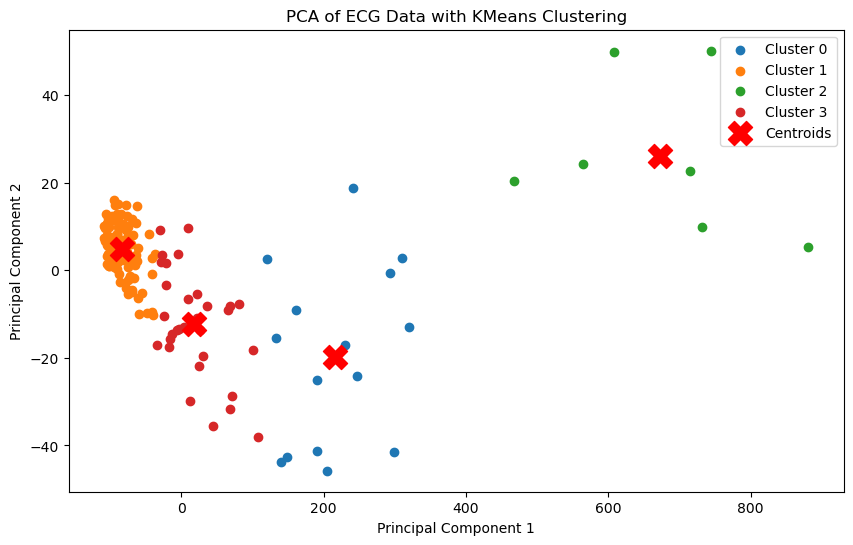

In [84]:
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA 
from scipy.stats import mode

pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train)
kmeans = KMeans(n_clusters=len(set(y_train)), random_state=42)  # n_clusters can be set to the number of classes
X_train_clusters = kmeans.fit_predict(X_train_pca)

# Plotting the Clusters
plt.figure(figsize=(10, 6))

# Scatter plot, colored by cluster assignment
for cluster in range(len(set(X_train_clusters))):
    mask = (X_train_clusters == cluster)
    plt.scatter(X_train_pca[mask, 0], X_train_pca[mask, 1], label=f'Cluster {cluster}')

# Plot centroids
centroids = kmeans.cluster_centers_
plt.scatter(centroids[:, 0], centroids[:, 1], s=300, c='red', marker='X', label='Centroids')

plt.title('PCA of ECG Data with KMeans Clustering')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
plt.show()

### Use of Wavelet-based Method 

In [85]:
# install a library 
# !pip install scaleogram   

import scaleogram as scg 
import time 
from tensorflow.keras import models
from tensorflow.keras import layers

In [86]:
# revisualize the origial data 
print(X)
print(y)
print(X_train)
print(X_test)
print(y_train)
print(y_test)

[[ 2.07950667  2.47154421  2.11223795 ... -1.13043018 -0.72425435
  -1.40589123]
 [-1.65165407 -1.78770287 -1.68872133 ...  0.95163106  0.62754998
  -0.02725009]
 [ 2.70069741  0.79649371 -0.82690109 ... -1.88586833 -0.91381135
  -0.33731127]
 ...
 [ 0.02047358  0.18260086  0.42179993 ... -0.92511947 -0.93318214
  -0.92948821]
 [ 0.3832811   0.51439533  0.62390183 ... -0.87642398 -0.72840523
  -0.53426001]
 [-0.12679147 -0.23104599 -0.20327237 ... -0.97381496 -0.33960583
  -0.23750617]]
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3
 3 3 3 3 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3]
[[ 4.18688468e-02  6.76373681e-01  4.57481357e-01 ...  7.

In [87]:
def create_segments_and_labels(X, save_option):
    window_size = 5
    sval = 0.002
    wavelet='cmor0.7-1.5'
    
    d1_   = []
    d1_1  = []
    for i in range(len(X) - window_size - 1): 
        wvar = np.var(d1[i:i+window_size])
        if wvar > sval:
            d1_1.append(X[i])
            


    time = np.arange(0, wv.size)
    scales = np.arange(1, 64, dtype=np.int32)


    cwt = scg.CWT()
    ax = scg.cws(time, signal=wv1, scales=scales, wavelet=wavelet, cmap='rainbow', 
                 cbar=None, yaxis='frequency', ylabel=None, xlabel=None, yscale=None, coi=False)
    
    


In [88]:
wavelet_model = models.Sequential([
    layers.Input(shape=(224, 224,3)),
    layers.Conv2D(64, (5,5), strides=(2,2), padding='valid', activation='relu'),

    layers.MaxPooling2D(pool_size=(2,2), padding='valid'),
    layers.Conv2D(32, (5,5), strides=(2,2), padding='valid', activation='relu'), 
    layers.MaxPooling2D(pool_size=(2,2), padding='valid'), 
    layers.Flatten(),

    layers.Dense(100, activation='relu'),
    layers.Dense(100, activation='relu'),
    layers.Dense(5, activation='softmax')
])

wavelet_model.summary()

Model: "sequential_4"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv2d_9 (Conv2D)            (None, 110, 110, 64)      4864      
_________________________________________________________________
max_pooling2d_8 (MaxPooling2 (None, 55, 55, 64)        0         
_________________________________________________________________
conv2d_10 (Conv2D)           (None, 26, 26, 32)        51232     
_________________________________________________________________
max_pooling2d_9 (MaxPooling2 (None, 13, 13, 32)        0         
_________________________________________________________________
flatten_4 (Flatten)          (None, 5408)              0         
_________________________________________________________________
dense_12 (Dense)             (None, 100)               540900    
_________________________________________________________________
dense_13 (Dense)             (None, 100)              

### RNN-based inference 

In [ ]:
model = tensorflow.keras.Sequential()
model.add(LST)

### Transformers-based inference 

In [89]:
from keras import layers

n_classes = len(np.unique(y))

def transformer_encoder(inputs, head_size, num_heads, ff_dim, dropout=0):
    # Attention and Normalization 
    x = layers.MultiHeadAttention(
        key_dim=head_size, num_heads=num_heads, dropout=dropout
    )(inputs, inputs)
    x = layers.Dropout(dropout)(x)
    x = layers.LayerNormalization(epsilon=1e-6)(x)
    res = x + inputs

    # Feed Forward Module
    x = layers.Conv1D(filters=ff_dim, kernel_size=1, activation='relu')(res)
    x = layers.Dropout(dropout)(x)
    x = layers.Conv1D(filters=inputs.shape[-1], kernel_size=1)(x)
    x = layers.LayerNormalization(epsilon=1e-6)(x)
    return x + res

def build_model(
        input_shape,
        head_size, 
        num_heads,
        ff_dim, 
        num_transformer_blocks, 
        mlp_units, 
        dropout=0,
        mlp_dropout=0,
): 
    inputs = keras.Input(shape=input_shape)
    x = inputs
    for _ in range(num_transformer_blocks):
        x = transformer_encoder(x, head_size=head_size, num_heads=num_heads, ff_dim=ff_dim, dropout=dropout)
    
    x = layers.GlobalAveragePooling1D(data_format='channels_last')(x)
    for dim in mlp_units:
        x = layers.Dense(dim, activation='relu')(x)
        x = layers.Dropout(mlp_dropout)(x)
    outputs = layers.Dense(n_classes, activation='softmax')
    return keras.Model(inputs, outputs)
    

In [91]:
input_shape = X_train.shape[1:]
print(input_shape)

(155, 11)


In [ ]:
model = build_model(
    input_shape,
    head_size=256,
    num_heads=4
    ff_dim=4,
    num_transformer_blocks=4,
    mlp_units=[128],
    mlp_dropout=0.4,
    dropout=0.25,
)